# YOLO approach accuracy analysis

YOLO triangulation 기반 approach의 endpoint 정확도를 계산한다.

가정:
- `approach_endpoint_xyz_error_points.csv`의 각 행은 approach 평가 sample 1개다.
- `inside_ok`가 있으면 기존 평가 기준의 성공 여부로 사용한다.
- 추가로 `XY_THRESHOLD_MM` 기준의 XY endpoint accuracy를 재계산한다.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

In [2]:
CWD = Path.cwd().resolve()
if (CWD / "src" / "ais").is_dir():
    WS_AIC_ROOT = CWD
elif (CWD / "ws_aic" / "src" / "ais").is_dir():
    WS_AIC_ROOT = CWD / "ws_aic"
else:
    candidates = [parent for parent in CWD.parents if (parent / "src" / "ais").is_dir()]
    if not candidates:
        raise FileNotFoundError(f"Could not find ws_aic root from cwd={CWD}")
    WS_AIC_ROOT = candidates[0]
EDA_OUTPUT_DIR = WS_AIC_ROOT / "src" / "ais" / "ais_eda" / "eda_outputs" / "yolo_approach_reachable_xyz"

ERROR_POINTS_CSV = EDA_OUTPUT_DIR / "approach_endpoint_xyz_error_points.csv"
ERROR_SUMMARY_CSV = EDA_OUTPUT_DIR / "approach_endpoint_xyz_error_summary.csv"
MATCH_SUMMARY_CSV = EDA_OUTPUT_DIR / "multiview_yolo_match_summary.csv"
CAMERA_SUMMARY_CSV = EDA_OUTPUT_DIR / "multiview_yolo_camera_summary.csv"
DETECTION_POINTS_CSV = EDA_OUTPUT_DIR / "multiview_yolo_detection_points.csv"

required_files = [ERROR_POINTS_CSV]
missing_files = [path for path in required_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError("Missing required analysis CSV(s):\n" + "\n".join(str(path) for path in missing_files))

WS_AIC_ROOT, ERROR_POINTS_CSV

(PosixPath('/home/whyz/aic_sejong/ws_aic'),
 PosixPath('/home/whyz/aic_sejong/ws_aic/src/ais/ais_eda/eda_outputs/yolo_approach_reachable_xyz/approach_endpoint_xyz_error_points.csv'))

In [3]:
errors = pd.read_csv(ERROR_POINTS_CSV)

numeric_cols = ["x_error_mm", "y_error_mm", "z_error_mm", "xy_error_mm"]
for col in numeric_cols:
    errors[col] = pd.to_numeric(errors[col], errors="coerce")

if "inside_ok" in errors:
    errors["inside_ok"] = errors["inside_ok"].map({True: True, False: False, "True": True, "False": False, "true": True, "false": False, 1: True, 0: False})
else:
    errors["inside_ok"] = np.nan
errors[["checkpoint", "task_type", "episode_index", "frame_index", "x_error_mm", "y_error_mm", "z_error_mm", "xy_error_mm", "inside_ok"]].head()

,checkpoint,task_type,episode_index,frame_index,x_error_mm,y_error_mm,z_error_mm,xy_error_mm,inside_ok
0,last_approach,nic,0,76,-4.241,-2.378,-7.179,4.862,True
1,first_insert,nic,0,77,-3.939,-2.410,-7.156,4.618,True
2,last_approach,nic,1,32,5.701,-1.473,-6.591,5.888,False
3,first_insert,nic,1,33,5.183,-2.119,-6.483,5.600,False
4,last_approach,nic,2,45,-0.790,0.926,-6.060,1.218,True


## Accuracy 기준

`inside_ok`는 기존 분석에서 계산된 성공 여부다. 아래 셀에서는 같은 데이터를 기준으로 XY threshold를 바꿔가며 accuracy를 다시 계산할 수 있다.

In [4]:
XY_THRESHOLD_MM = 5.0
Z_ABS_THRESHOLD_MM = None  # 예: 10.0으로 바꾸면 |z error|도 성공 조건에 포함

errors = errors.copy()
errors["xy_ok"] = errors["xy_error_mm"] <= XY_THRESHOLD_MM
if Z_ABS_THRESHOLD_MM is None:
    errors["threshold_ok"] = errors["xy_ok"]
else:
    errors["z_ok"] = errors["z_error_mm"].abs() <= Z_ABS_THRESHOLD_MM
    errors["threshold_ok"] = errors["xy_ok"] & errors["z_ok"]

overall = pd.Series(
    {
        "n": len(errors),
        "inside_ok_accuracy_pct": errors["inside_ok"].mean() * 100 if "inside_ok" in errors else np.nan,
        "threshold_accuracy_pct": errors["threshold_ok"].mean() * 100,
        "xy_mean_mm": errors["xy_error_mm"].mean(),
        "xy_median_mm": errors["xy_error_mm"].median(),
        "xy_p90_mm": errors["xy_error_mm"].quantile(0.90),
        "xy_max_mm": errors["xy_error_mm"].max(),
        "z_abs_mean_mm": errors["z_error_mm"].abs().mean(),
        "z_abs_p90_mm": errors["z_error_mm"].abs().quantile(0.90),
    }
)
overall.to_frame("value")

,value
n,14.000
inside_ok_accuracy_pct,57.143
threshold_accuracy_pct,57.143
xy_mean_mm,4.260
xy_median_mm,4.740
xy_p90_mm,8.714
xy_max_mm,9.926
z_abs_mean_mm,6.395
z_abs_p90_mm,12.212


In [5]:
group_cols = ["checkpoint", "task_type"]
accuracy_by_group = (
    errors.groupby(group_cols, dropna=False)
    .agg(
        n=("xy_error_mm", "size"),
        inside_ok_accuracy_pct=("inside_ok", lambda s: s.mean() * 100),
        threshold_accuracy_pct=("threshold_ok", lambda s: s.mean() * 100),
        xy_mean_mm=("xy_error_mm", "mean"),
        xy_median_mm=("xy_error_mm", "median"),
        xy_p90_mm=("xy_error_mm", lambda s: s.quantile(0.90)),
        xy_max_mm=("xy_error_mm", "max"),
        x_bias_mm=("x_error_mm", "mean"),
        y_bias_mm=("y_error_mm", "mean"),
        z_bias_mm=("z_error_mm", "mean"),
    )
    .reset_index()
)
accuracy_by_group

,checkpoint,task_type,n,inside_ok_accuracy_pct,threshold_accuracy_pct,xy_mean_mm,xy_median_mm,xy_p90_mm,xy_max_mm,x_bias_mm,y_bias_mm,z_bias_mm
0,first_insert,nic,5,80.000,80.000,2.745,1.307,5.207,5.600,0.347,-0.872,-5.663
1,first_insert,sc,2,0.000,0.000,7.745,7.745,9.490,9.926,7.062,-2.634,-8.046
2,last_approach,nic,5,80.000,80.000,3.015,2.299,5.478,5.888,0.498,-0.592,-5.799
3,last_approach,sc,2,0.000,0.000,7.676,7.676,9.475,9.924,7.038,-2.555,-8.064


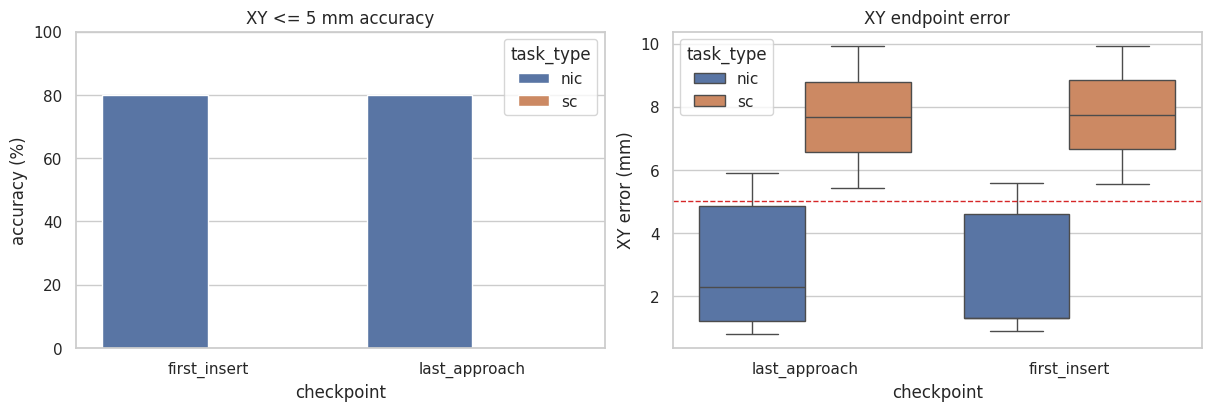

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(
    data=accuracy_by_group,
    x="checkpoint",
    y="threshold_accuracy_pct",
    hue="task_type",
    ax=axes[0],
)
axes[0].set_ylim(0, 100)
axes[0].set_title(f"XY <= {XY_THRESHOLD_MM:g} mm accuracy")
axes[0].set_ylabel("accuracy (%)")
axes[0].set_xlabel("checkpoint")

sns.boxplot(
    data=errors,
    x="checkpoint",
    y="xy_error_mm",
    hue="task_type",
    ax=axes[1],
)
axes[1].axhline(XY_THRESHOLD_MM, color="tab:red", linestyle="--", linewidth=1, label="threshold")
axes[1].set_title("XY endpoint error")
axes[1].set_ylabel("XY error (mm)")
axes[1].set_xlabel("checkpoint")
plt.show()

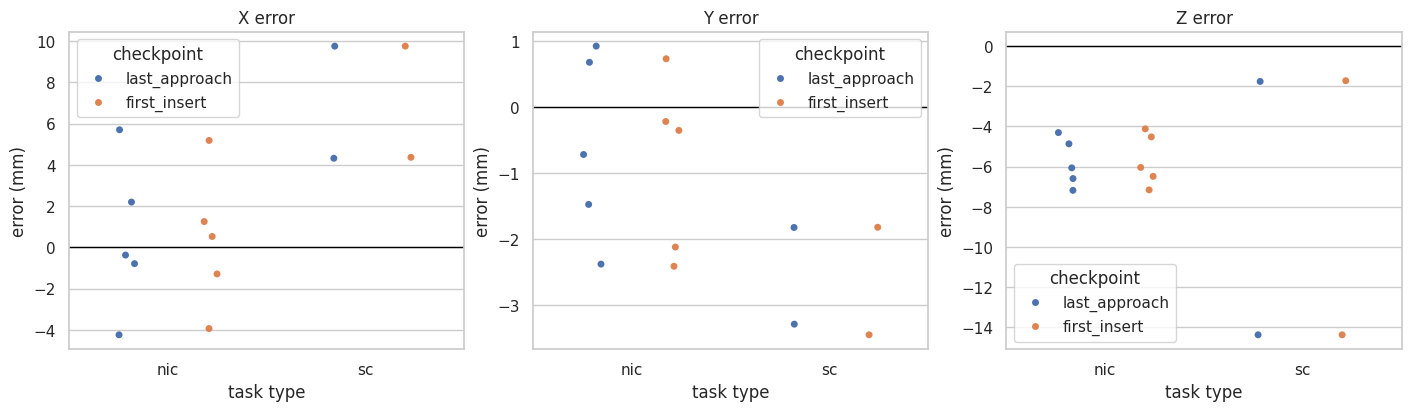

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, col, title in zip(
    axes,
    ["x_error_mm", "y_error_mm", "z_error_mm"],
    ["X error", "Y error", "Z error"],
):
    sns.stripplot(data=errors, x="task_type", y=col, hue="checkpoint", dodge=True, ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("error (mm)")
    ax.set_xlabel("task type")
plt.show()

## Detection quality와 accuracy 관계

multi-view detection summary가 있으면 view 수, confidence와 endpoint error를 함께 확인한다.

In [8]:
if MATCH_SUMMARY_CSV.is_file():
    match_summary = pd.read_csv(MATCH_SUMMARY_CSV)
    display(match_summary)
else:
    match_summary = pd.DataFrame()
    print(f"skip: {MATCH_SUMMARY_CSV} not found")

,checkpoint,task_type,n,at_least_2_views_pct,all_3_views_pct,at_least_2_ok_conf_pct,all_3_ok_conf_pct,conf_min_mean
0,first_insert,nic,5,100.000,80.000,100.000,60.000,0.445
1,first_insert,sc,2,100.000,100.000,0.000,0.000,0.066
2,last_approach,nic,5,100.000,80.000,100.000,40.000,0.473
3,last_approach,sc,2,100.000,100.000,0.000,0.000,0.162


In [9]:
if CAMERA_SUMMARY_CSV.is_file():
    camera_summary = pd.read_csv(CAMERA_SUMMARY_CSV)
    display(camera_summary)
else:
    camera_summary = pd.DataFrame()
    print(f"skip: {CAMERA_SUMMARY_CSV} not found")

,checkpoint,task_type,camera,n,frame_read_pct,detect_pct,ok_conf_pct,conf_mean,conf_p10,conf_p50,area_mean,area_p50
0,first_insert,nic,center,5,100.000,100.000,100.000,0.851,0.812,0.859,0.002,0.002
1,first_insert,nic,left,5,100.000,100.000,100.000,0.879,0.862,0.880,0.002,0.002
2,first_insert,nic,right,5,100.000,80.000,60.000,0.445,0.037,0.633,0.002,0.002
3,first_insert,sc,center,2,100.000,100.000,50.000,0.584,0.397,0.584,0.004,0.004
4,first_insert,sc,left,2,100.000,100.000,0.000,0.291,0.148,0.291,0.004,0.004
5,first_insert,sc,right,2,100.000,100.000,50.000,0.280,0.072,0.280,0.002,0.002
6,last_approach,nic,center,5,100.000,100.000,100.000,0.841,0.782,0.857,0.002,0.002
7,last_approach,nic,left,5,100.000,100.000,100.000,0.877,0.856,0.881,0.002,0.002
8,last_approach,nic,right,5,100.000,80.000,40.000,0.473,0.117,0.414,0.002,0.002
9,last_approach,sc,center,2,100.000,100.000,50.000,0.574,0.379,0.574,0.004,0.004


In [10]:
if DETECTION_POINTS_CSV.is_file():
    detections = pd.read_csv(DETECTION_POINTS_CSV)
    sample_quality = (
        detections.groupby(["sample_id", "checkpoint", "task_type"], dropna=False)
        .agg(
            detected_views=("detected", "sum"),
            ok_conf_views=("detected_ok_conf", "sum"),
            min_confidence=("confidence", "min"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )
    errors_with_quality = errors.reset_index(names="sample_id").merge(
        sample_quality,
        on=["sample_id", "checkpoint", "task_type"],
        how="left",
    )
    display(errors_with_quality[["sample_id", "checkpoint", "task_type", "xy_error_mm", "threshold_ok", "detected_views", "ok_conf_views", "min_confidence"]])
else:
    detections = pd.DataFrame()
    errors_with_quality = errors.copy()
    print(f"skip: {DETECTION_POINTS_CSV} not found")

,sample_id,checkpoint,task_type,xy_error_mm,threshold_ok,detected_views,ok_conf_views,min_confidence
0,0,last_approach,nic,4.862,True,3,2,0.414
1,1,first_insert,nic,4.618,True,3,3,0.633
2,2,last_approach,nic,5.888,False,3,2,0.291
3,3,first_insert,nic,5.600,False,3,2,0.092
4,4,last_approach,nic,1.218,True,2,2,0.000
5,5,first_insert,nic,0.904,True,2,2,0.000
6,6,last_approach,nic,0.808,True,3,3,0.868
7,7,first_insert,nic,1.307,True,3,3,0.868
8,8,last_approach,nic,2.299,True,3,3,0.793
9,9,first_insert,nic,1.298,True,3,3,0.635


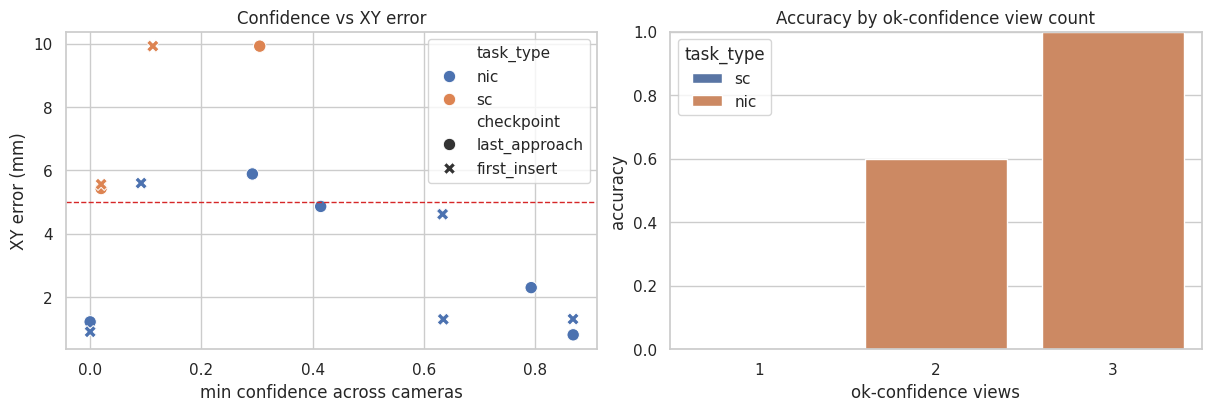

In [11]:
if {"detected_views", "ok_conf_views"}.issubset(errors_with_quality.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    sns.scatterplot(
        data=errors_with_quality,
        x="min_confidence",
        y="xy_error_mm",
        hue="task_type",
        style="checkpoint",
        s=80,
        ax=axes[0],
    )
    axes[0].axhline(XY_THRESHOLD_MM, color="tab:red", linestyle="--", linewidth=1)
    axes[0].set_title("Confidence vs XY error")
    axes[0].set_xlabel("min confidence across cameras")
    axes[0].set_ylabel("XY error (mm)")

    quality_accuracy = (
        errors_with_quality.groupby(["ok_conf_views", "task_type"], dropna=False)["threshold_ok"]
        .mean()
        .reset_index(name="accuracy")
    )
    sns.barplot(data=quality_accuracy, x="ok_conf_views", y="accuracy", hue="task_type", ax=axes[1])
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Accuracy by ok-confidence view count")
    axes[1].set_xlabel("ok-confidence views")
    axes[1].set_ylabel("accuracy")
    plt.show()

## Worst cases

큰 오차 sample을 확인해 어떤 task/checkpoint에서 실패하는지 본다.

In [12]:
worst_cols = [
    "checkpoint",
    "task_type",
    "episode_index",
    "frame_index",
    "x_error_mm",
    "y_error_mm",
    "z_error_mm",
    "xy_error_mm",
    "inside_ok",
    "threshold_ok",
]
errors.sort_values("xy_error_mm", ascending=False)[worst_cols].head(10)

,checkpoint,task_type,episode_index,frame_index,x_error_mm,y_error_mm,z_error_mm,xy_error_mm,inside_ok,threshold_ok
13,first_insert,sc,6,86,9.758,-1.819,-14.369,9.926,False,False
12,last_approach,sc,6,85,9.756,-1.823,-14.368,9.924,False,False
2,last_approach,nic,1,32,5.701,-1.473,-6.591,5.888,False,False
3,first_insert,nic,1,33,5.183,-2.119,-6.483,5.600,False,False
11,first_insert,sc,5,85,4.365,-3.449,-1.723,5.563,False,False
10,last_approach,sc,5,84,4.320,-3.288,-1.760,5.429,False,False
0,last_approach,nic,0,76,-4.241,-2.378,-7.179,4.862,True,True
1,first_insert,nic,0,77,-3.939,-2.410,-7.156,4.618,True,True
8,last_approach,nic,4,45,2.195,0.681,-4.305,2.299,True,True
7,first_insert,nic,3,45,-1.289,-0.217,-4.519,1.307,True,True


In [13]:
if ERROR_SUMMARY_CSV.is_file():
    existing_summary = pd.read_csv(ERROR_SUMMARY_CSV)
    display(existing_summary)
else:
    print(f"skip: {ERROR_SUMMARY_CSV} not found")

,checkpoint,task_type,n,ok_pct,xy_mean_mm,xy_p50_mm,xy_p90_mm,xy_p95_mm,xy_max_mm,x_mean_mm,x_std_mm,x_p05_mm,x_p50_mm,x_p95_mm,x_min_mm,x_max_mm,x_range_mm,y_mean_mm,y_std_mm,y_p05_mm,y_p50_mm,y_p95_mm,y_min_mm,y_max_mm,y_range_mm,z_mean_mm,z_std_mm,z_p05_mm,z_p50_mm,z_p95_mm,z_min_mm,z_max_mm,z_range_mm
0,first_insert,nic,5,80.000,2.745,1.307,5.207,5.403,5.600,0.347,3.009,-3.409,0.527,4.397,-3.939,5.183,9.122,-0.872,1.200,-2.352,-0.351,0.544,-2.410,0.735,3.145,-5.663,1.161,-7.022,-6.040,-4.198,-7.156,-4.118,3.038
1,first_insert,sc,2,0.000,7.745,7.745,9.490,9.708,9.926,7.062,2.696,4.635,7.062,9.489,4.365,9.758,5.393,-2.634,0.815,-3.368,-2.634,-1.901,-3.449,-1.819,1.630,-8.046,6.323,-13.736,-8.046,-2.356,-14.369,-1.723,12.645
2,last_approach,nic,5,80.000,3.015,2.299,5.478,5.683,5.888,0.498,3.312,-3.551,-0.374,5.000,-4.241,5.701,9.943,-0.592,1.257,-2.197,-0.716,0.877,-2.378,0.926,3.304,-5.799,1.069,-7.061,-6.060,-4.416,-7.179,-4.305,2.874
3,last_approach,sc,2,0.000,7.676,7.676,9.475,9.700,9.924,7.038,2.718,4.592,7.038,9.484,4.320,9.756,5.436,-2.555,0.733,-3.214,-2.555,-1.896,-3.288,-1.823,1.465,-8.064,6.304,-13.738,-8.064,-2.390,-14.368,-1.760,12.609
